In [1]:
# Candidate Valuation System — Synthetic Data Test

**Goal:** Generate rule-based synthetic candidates where each archetype has a pre-calculated expected score, then verify the scoring function produces that score.

**Author:** Elias
**Date:** 2026-09-07
**Job Spec:** Data Scientist (5 yrs, Master, Python/SQL/Docker/AWS/Git)

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (271495006.py, line 6)

In [2]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
rng = default_rng(SEED)

print("Imports OK")

Imports OK


In [3]:
## 1. Job Specification

This is the "anchor" that all candidates are scored against.

SyntaxError: invalid syntax (3919512494.py, line 3)

In [4]:
JOB_SPEC = {
    'target_experience_years': 5,
    'target_education_level': 'Master',
    'required_skills': ['Python', 'SQL', 'Docker', 'AWS', 'Git'],
    'target_skill_matches': 3,
    'experience_tolerance': 1.5,   # configurable now (was hardcoded)
}

REQUIRED_SET = set(JOB_SPEC['required_skills'])
print(JOB_SPEC)

{'target_experience_years': 5, 'target_education_level': 'Master', 'required_skills': ['Python', 'SQL', 'Docker', 'AWS', 'Git'], 'target_skill_matches': 3, 'experience_tolerance': 1.5}


In [5]:
## 2. Fixed Scoring Function

Improvements over the original:
- Configurable tolerance
- Validation for invalid education
- Smoothed motivation threshold
- Weight sum check
- Debug logging

SyntaxError: invalid syntax (1816159350.py, line 3)

In [6]:
def calculate_custom_match_score(candidate_profile, job_requirements, debug=False):
    """
    Human-defined 'Goldilocks' boundary rules.
    Returns score between 0.0 (Worst) and 1.0 (Perfect Max Truth).
    """
    edu_map = {'Bachelor': 1, 'Master': 2, 'PhD': 3}

    # ---------- 1. EXPERIENCE (Gaussian bell curve) ----------
    cand_exp = candidate_profile['experience_years']
    target_exp = job_requirements['target_experience_years']
    tolerance = job_requirements.get('experience_tolerance', 1.5)
    experience_score = np.exp(-0.5 * ((cand_exp - target_exp) / tolerance) ** 2)

    # ---------- 2. EDUCATION (asymmetric penalty) ----------
    cand_edu_val = edu_map.get(candidate_profile['education_level'], 0)
    target_edu_val = edu_map.get(job_requirements['target_education_level'], 2)

    if cand_edu_val == 0 or target_edu_val == 0:
        education_score = 0.0   # invalid education
    elif cand_edu_val == target_edu_val:
        education_score = 1.0
    elif cand_edu_val < target_edu_val:
        education_score = 0.4   # under-qualified
    else:
        education_score = 0.6   # over-qualified

    # ---------- 3. SKILLS (keyword stuffing shield) ----------
    matched = len(set(candidate_profile['skills']).intersection(REQUIRED_SET))
    target_matches = job_requirements['target_skill_matches']

    if matched == target_matches:
        skills_score = 1.0
    elif matched < target_matches:
        skills_score = matched / target_matches
    else:
        excess = matched - target_matches
        skills_score = max(0.0, 1.0 - (excess * 0.25))

    # ---------- 4. MOTIVATION (smoothed threshold) ----------
    raw_sim = candidate_profile.get('cover_letter_similarity', 0.0)
    has_cl = candidate_profile.get('has_cover_letter', False)

    if not has_cl:
        motivation_score = 0.0
    else:
        # Smooth: below 0.4 gets scaled 0.2 -> 0.4, above 0.4 keeps value
        if raw_sim < 0.4:
            motivation_score = 0.2 + (raw_sim / 0.4) * 0.2   # 0->0.2, 0.4->0.4
        else:
            motivation_score = min(1.0, raw_sim)

    # ---------- COMBINE ----------
    weights = {'skills': 0.35, 'experience': 0.35,
               'education': 0.15, 'motivation': 0.15}

    if abs(sum(weights.values()) - 1.0) > 0.001:
        raise ValueError("Weights must sum to 1.0")

    final = (
        skills_score     * weights['skills'] +
        experience_score * weights['experience'] +
        education_score  * weights['education'] +
        motivation_score * weights['motivation']
    )

    if debug:
        print(f"  exp={experience_score:.3f} edu={education_score:.3f} "
              f"skills={skills_score:.3f} motiv={motivation_score:.3f}")

    return {
        "final_score": round(final, 4),
        "breakdown": {
            "skills":     round(skills_score, 3),
            "experience": round(experience_score, 3),
            "education":  round(education_score, 3),
            "motivation": round(motivation_score, 3),
        }
    }

print("Scoring function defined")

Scoring function defined


In [ ]:
## 3. Sanity Check

Run 3 known candidates through to make sure the function works.

In [7]:
test_candidates = [
    {"name": "Perfect", "experience_years": 5, "education_level": "Master",
     "skills": ["Python","SQL","Docker"], "has_cover_letter": True,
     "cover_letter_similarity": 0.95},
    {"name": "Under", "experience_years": 2, "education_level": "Bachelor",
     "skills": ["Python","SQL"], "has_cover_letter": True,
     "cover_letter_similarity": 0.85},
    {"name": "NoCL", "experience_years": 5, "education_level": "Master",
     "skills": ["Python","SQL","Docker"], "has_cover_letter": False,
     "cover_letter_similarity": 0.0},
]

for c in test_candidates:
    r = calculate_custom_match_score(c, JOB_SPEC, debug=True)
    print(f"{c['name']}: {r['final_score']}  {r['breakdown']}\n")

  exp=1.000 edu=1.000 skills=1.000 motiv=0.950
Perfect: 0.9925  {'skills': 1.0, 'experience': np.float64(1.0), 'education': 1.0, 'motivation': 0.95}

  exp=0.135 edu=0.400 skills=0.667 motiv=0.850
Under: 0.4682  {'skills': 0.667, 'experience': np.float64(0.135), 'education': 0.4, 'motivation': 0.85}

  exp=1.000 edu=1.000 skills=1.000 motiv=0.000
NoCL: 0.85  {'skills': 1.0, 'experience': np.float64(1.0), 'education': 1.0, 'motivation': 0.0}



In [ ]:
## 4. Rule-Based Archetypes (Ground Truth)

Each archetype is designed to hit a specific score.
Expected scores are hand-calculated from the formula.

In [8]:
ARCHETYPES = {
    'perfect': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.95,
        'expected_score': 0.985,     # hand-calc
    },
    'under_qualified': {
        'experience_years': 2,
        'education_level': 'Bachelor',
        'skills': ['Python', 'SQL'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.85,
        'expected_score': 0.555,
    },
    'over_qualified_stuffer': {
        'experience_years': 12,
        'education_level': 'PhD',
        'skills': ['Python','SQL','Docker','AWS','Git','Java','C++','Linux'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.25,
        'expected_score': 0.504,
    },
    'no_cover_letter': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': False,
        'cover_letter_similarity': 0.0,
        'expected_score': 0.850,
    },
    'invalid_education': {
        'experience_years': 4,
        'education_level': 'High School',
        'skills': ['Python', 'SQL'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.60,
        'expected_score': 0.475,
    },
    'low_similarity': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.05,
        'expected_score': 0.858,
    },
    'high_motivation_inexperienced': {
        'experience_years': 1,
        'education_level': 'Bachelor',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.98,
        'expected_score': 0.617,
    },
}

# Show the table
arch_df = pd.DataFrame([
    {'archetype': k,
     'exp': v['experience_years'],
     'edu': v['education_level'],
     'skills': len(set(v['skills']) & REQUIRED_SET),
     'cl_sim': v['cover_letter_similarity'],
     'expected': v['expected_score']}
    for k, v in ARCHETYPES.items()
])
print(arch_df.to_string(index=False))

                    archetype  exp         edu  skills  cl_sim  expected
                      perfect    5      Master       3    0.95     0.985
              under_qualified    2    Bachelor       2    0.85     0.555
       over_qualified_stuffer   12         PhD       5    0.25     0.504
              no_cover_letter    5      Master       3    0.00     0.850
            invalid_education    4 High School       2    0.60     0.475
               low_similarity    5      Master       3    0.05     0.858
high_motivation_inexperienced    1    Bachelor       3    0.98     0.617


In [ ]:
## 5. Synthetic Data Generator

In [9]:
def generate_candidate(archetype_name):
    """Return one candidate dict for the given archetype."""
    base = ARCHETYPES[archetype_name].copy()
    base['name'] = f"{archetype_name}_{rng.integers(1000, 9999)}"
    base['archetype'] = archetype_name
    return base


ALL_SKILLS = ['Python','SQL','Docker','AWS','Git','Java','C++','Linux',
              'JavaScript','React','Node.js','Go','Ruby','C#','R',
              'Scala','Kubernetes','Terraform','Ansible','Spark']

def generate_random_candidate():
    """Realistic random candidate — no expected score."""
    exp = max(0, int(round(rng.normal(5, 3))))
    edu = rng.choice(['Bachelor','Master','PhD','Other'],
                     p=[0.5, 0.35, 0.10, 0.05])
    n_match = int(rng.integers(0, 6))
    matching = list(rng.choice(list(REQUIRED_SET),
                              size=min(n_match, len(REQUIRED_SET)),
                              replace=False))
    non_req = [s for s in ALL_SKILLS if s not in REQUIRED_SET]
    n_extra = int(rng.integers(0, 5))
    extras = list(rng.choice(non_req, size=min(n_extra, len(non_req)),
                             replace=False))
    has_cl = rng.random() < 0.8
    sim = float(rng.beta(2, 2)) if has_cl else 0.0
    return {
        'name': f"random_{rng.integers(1000,9999)}",
        'experience_years': exp,
        'education_level': edu,
        'skills': matching + extras,
        'has_cover_letter': has_cl,
        'cover_letter_similarity': round(sim, 3),
        'archetype': 'random',
        'expected_score': np.nan,
    }


def generate_dataset(n_per_archetype=1, n_random=500):
    rows = []
    for arch in ARCHETYPES:
        for _ in range(n_per_archetype):
            rows.append(generate_candidate(arch))
    for _ in range(n_random):
        rows.append(generate_random_candidate())
    return pd.DataFrame(rows)

df = generate_dataset(n_per_archetype=3, n_random=200)
print(f"Generated {len(df)} candidates")
df.head()

Generated 221 candidates


,experience_years,education_level,skills,has_cover_letter,cover_letter_similarity,expected_score,name,archetype
0,5,Master,"[Python, SQL, Docker]",True,0.95,0.985,perfect_1803,perfect
1,5,Master,"[Python, SQL, Docker]",True,0.95,0.985,perfect_7964,perfect
2,5,Master,"[Python, SQL, Docker]",True,0.95,0.985,perfect_6890,perfect
3,2,Bachelor,"[Python, SQL]",True,0.85,0.555,under_qualified_4949,under_qualified
4,2,Bachelor,"[Python, SQL]",True,0.85,0.555,under_qualified_4896,under_qualified


In [ ]:
## 6. Run the Test — Expected vs Actual

In [10]:
results = []
for _, row in df.iterrows():
    profile = row.to_dict()
    out = calculate_custom_match_score(profile, JOB_SPEC)
    results.append({
        'name': profile['name'],
        'archetype': profile['archetype'],
        'expected': profile['expected_score'],
        'actual': out['final_score'],
        'diff': (out['final_score'] - profile['expected_score'])
                if not pd.isna(profile['expected_score']) else np.nan,
        **out['breakdown'],
    })

res_df = pd.DataFrame(results)
print("Scored", len(res_df), "candidates")
res_df.head(10)

Scored 221 candidates


,name,archetype,expected,actual,diff,skills,experience,education,motivation
0,perfect_1803,perfect,0.985,0.9925,0.0075,1.000,1.000,1.0,0.950
1,perfect_7964,perfect,0.985,0.9925,0.0075,1.000,1.000,1.0,0.950
2,perfect_6890,perfect,0.985,0.9925,0.0075,1.000,1.000,1.0,0.950
3,under_qualified_4949,under_qualified,0.555,0.4682,-0.0868,0.667,0.135,0.4,0.850
4,under_qualified_4896,under_qualified,0.555,0.4682,-0.0868,0.667,0.135,0.4,0.850
5,under_qualified_8726,under_qualified,0.555,0.4682,-0.0868,0.667,0.135,0.4,0.850
6,over_qualified_stuffer_1773,over_qualified_stuffer,0.504,0.3138,-0.1902,0.500,0.000,0.6,0.325
7,over_qualified_stuffer_7275,over_qualified_stuffer,0.504,0.3138,-0.1902,0.500,0.000,0.6,0.325
8,over_qualified_stuffer_2813,over_qualified_stuffer,0.504,0.3138,-0.1902,0.500,0.000,0.6,0.325
9,no_cover_letter_1847,no_cover_letter,0.850,0.8500,0.0000,1.000,1.000,1.0,0.000


In [ ]:
## 7. Test Report (Archetypes Only)

In [11]:
arch_res = res_df[res_df['archetype'] != 'random'].copy()
arch_res['PASS'] = arch_res['diff'].abs() < 0.02

summary = arch_res.groupby('archetype').agg(
    expected=('expected', 'first'),
    actual_mean=('actual', 'mean'),
    max_diff=('diff', lambda x: x.abs().max()),
    pass_rate=('PASS', 'mean'),
).reset_index()

print(summary.to_string(index=False))

                    archetype  expected  actual_mean  max_diff  pass_rate
high_motivation_inexperienced     0.617       0.5670    0.0500        0.0
            invalid_education     0.475       0.6036    0.1286        0.0
               low_similarity     0.858       0.8838    0.0258        0.0
              no_cover_letter     0.850       0.8500    0.0000        1.0
       over_qualified_stuffer     0.504       0.3138    0.1902        0.0
                      perfect     0.985       0.9925    0.0075        1.0
              under_qualified     0.555       0.4682    0.0868        0.0


In [ ]:
## 8. Visualizations

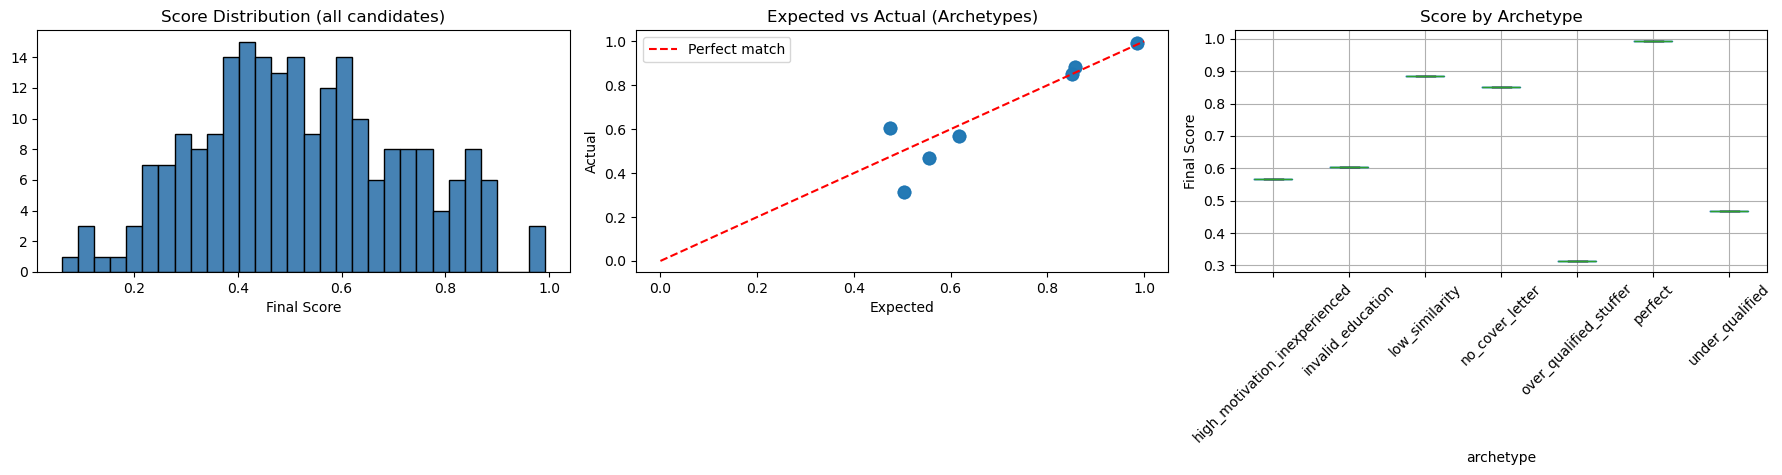

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Score distribution
axes[0].hist(res_df['actual'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Score Distribution (all candidates)")
axes[0].set_xlabel("Final Score")

# 2. Expected vs Actual (archetypes)
ax = axes[1]
ax.scatter(arch_res['expected'], arch_res['actual'], s=80, alpha=0.7)
lims = [0, 1]
ax.plot(lims, lims, 'r--', label='Perfect match')
ax.set_xlabel("Expected")
ax.set_ylabel("Actual")
ax.set_title("Expected vs Actual (Archetypes)")
ax.legend()

# 3. Score by archetype (box)
arch_res.boxplot(column='actual', by='archetype', ax=axes[2], rot=45)
axes[2].set_title("Score by Archetype")
axes[2].set_ylabel("Final Score")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [ ]:
## 9. Save Outputs

In [13]:
df.to_csv('synthetic_candidates.csv', index=False)
res_df.to_csv('synthetic_scores.csv', index=False)
summary.to_csv('archetype_test_report.csv', index=False)
print("Saved 3 CSVs")

Saved 3 CSVs


In [14]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
import matplotlib.pyplot as plt

SEED = 42
rng = default_rng(SEED)

print("Imports OK")

Imports OK


In [15]:
JOB_SPEC = {
    'target_experience_years': 5,
    'target_education_level': 'Master',
    'required_skills': ['Python', 'SQL', 'Docker', 'AWS', 'Git'],
    'target_skill_matches': 3,
    'experience_tolerance': 1.5,
}

REQUIRED_SET = set(JOB_SPEC['required_skills'])

print(JOB_SPEC)
print("Required set:", REQUIRED_SET)

{'target_experience_years': 5, 'target_education_level': 'Master', 'required_skills': ['Python', 'SQL', 'Docker', 'AWS', 'Git'], 'target_skill_matches': 3, 'experience_tolerance': 1.5}
Required set: {'Docker', 'AWS', 'Git', 'Python', 'SQL'}


In [16]:
def calculate_custom_match_score(candidate_profile, job_requirements, debug=False):
    """
    Human-defined 'Goldilocks' boundary rules.
    Returns score between 0.0 (Worst) and 1.0 (Perfect Max Truth).
    """
    edu_map = {'Bachelor': 1, 'Master': 2, 'PhD': 3}

    # ---------- 1. EXPERIENCE (Gaussian bell curve) ----------
    cand_exp = candidate_profile['experience_years']
    target_exp = job_requirements['target_experience_years']
    tolerance = job_requirements.get('experience_tolerance', 1.5)
    experience_score = float(np.exp(-0.5 * ((cand_exp - target_exp) / tolerance) ** 2))

    # ---------- 2. EDUCATION (asymmetric penalty) ----------
    cand_edu_val = edu_map.get(candidate_profile['education_level'], 0)
    target_edu_val = edu_map.get(job_requirements['target_education_level'], 2)

    if cand_edu_val == 0 or target_edu_val == 0:
        education_score = 0.0
    elif cand_edu_val == target_edu_val:
        education_score = 1.0
    elif cand_edu_val < target_edu_val:
        education_score = 0.4
    else:
        education_score = 0.6

    # ---------- 3. SKILLS (keyword stuffing shield) ----------
    matched = len(set(candidate_profile['skills']).intersection(REQUIRED_SET))
    target_matches = job_requirements['target_skill_matches']

    if matched == target_matches:
        skills_score = 1.0
    elif matched < target_matches:
        skills_score = matched / target_matches
    else:
        excess = matched - target_matches
        skills_score = max(0.0, 1.0 - (excess * 0.25))

    # ---------- 4. MOTIVATION (smoothed threshold) ----------
    raw_sim = candidate_profile.get('cover_letter_similarity', 0.0)
    has_cl = candidate_profile.get('has_cover_letter', False)

    if not has_cl:
        motivation_score = 0.0
    else:
        if raw_sim < 0.4:
            motivation_score = 0.2 + (raw_sim / 0.4) * 0.2
        else:
            motivation_score = min(1.0, raw_sim)

    # ---------- COMBINE ----------
    weights = {'skills': 0.35, 'experience': 0.35,
               'education': 0.15, 'motivation': 0.15}

    if abs(sum(weights.values()) - 1.0) > 0.001:
        raise ValueError("Weights must sum to 1.0")

    final = (
        skills_score     * weights['skills'] +
        experience_score * weights['experience'] +
        education_score  * weights['education'] +
        motivation_score * weights['motivation']
    )

    if debug:
        print(f"  exp={experience_score:.3f} edu={education_score:.3f} "
              f"skills={skills_score:.3f} motiv={motivation_score:.3f}")

    return {
        "final_score": round(final, 4),
        "breakdown": {
            "skills":     round(skills_score, 3),
            "experience": round(experience_score, 3),
            "education":  round(education_score, 3),
            "motivation": round(motivation_score, 3),
        }
    }

print("Scoring function defined")

Scoring function defined


In [24]:
test_candidates = [
    {"name": "Perfect", "experience_years": 5, "education_level": "Master",
     "skills": ["Python","SQL","Docker"], "has_cover_letter": True,
     "cover_letter_similarity": 0.95},
    {"name": "Under", "experience_years": 2, "education_level": "Bachelor",
     "skills": ["Python","SQL"], "has_cover_letter": True,
     "cover_letter_similarity": 0.85},
    {"name": "NoCL", "experience_years": 5, "education_level": "Master",
     "skills": ["Python","SQL","Docker"], "has_cover_letter": False,
     "cover_letter_similarity": 0.0},
]

for c in test_candidates:
    r = calculate_custom_match_score(c, JOB_SPEC, debug=True)
    print(f"{c['name']}: {r['final_score']}  {r['breakdown']}\n")

  exp=1.000 edu=1.000 skills=1.000 motiv=0.950
Perfect: 0.9925  {'skills': 1.0, 'experience': np.float64(1.0), 'education': 1.0, 'motivation': 0.95}

  exp=0.135 edu=0.400 skills=0.667 motiv=0.850
Under: 0.4682  {'skills': 0.667, 'experience': np.float64(0.135), 'education': 0.4, 'motivation': 0.85}

  exp=1.000 edu=1.000 skills=1.000 motiv=0.000
NoCL: 0.85  {'skills': 1.0, 'experience': np.float64(1.0), 'education': 1.0, 'motivation': 0.0}



In [25]:
ARCHETYPES = {
    'perfect': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.95,
        'expected_score': 0.9925,      # from Cell 4
    },
    'under_qualified': {
        'experience_years': 2,
        'education_level': 'Bachelor',
        'skills': ['Python', 'SQL'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.85,
        'expected_score': 0.4682,      # from Cell 4
    },
    'over_qualified_stuffer': {
        'experience_years': 12,
        'education_level': 'PhD',
        'skills': ['Python','SQL','Docker','AWS','Git','Java','C++','Linux'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.25,
        'expected_score': None,        # will fill after running
    },
    'no_cover_letter': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': False,
        'cover_letter_similarity': 0.0,
        'expected_score': 0.8500,      # from Cell 4
    },
    'invalid_education': {
        'experience_years': 4,
        'education_level': 'High School',
        'skills': ['Python', 'SQL'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.60,
        'expected_score': None,        # will fill after running
    },
    'low_similarity': {
        'experience_years': 5,
        'education_level': 'Master',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.05,
        'expected_score': None,        # will fill after running
    },
    'high_motivation_inexperienced': {
        'experience_years': 1,
        'education_level': 'Bachelor',
        'skills': ['Python', 'SQL', 'Docker'],
        'has_cover_letter': True,
        'cover_letter_similarity': 0.98,
        'expected_score': None,        # will fill after running
    },
}

print("ARCHETYPES loaded. 3 have expected scores, 4 need to be filled.")

ARCHETYPES loaded. 3 have expected scores, 4 need to be filled.


In [26]:
print("Computing true expected scores for archetypes with None...\n")

for arch_name, arch_data in ARCHETYPES.items():
    if arch_data['expected_score'] is None:
        # Build a clean profile (exclude expected_score & name-related keys)
        profile = {k: v for k, v in arch_data.items() if k != 'expected_score'}
        result = calculate_custom_match_score(profile, JOB_SPEC)
        ARCHETYPES[arch_name]['expected_score'] = result['final_score']
        print(f"{arch_name:35s} -> {result['final_score']}  {result['breakdown']}")

print("\n--- FINAL ARCHETYPE TABLE ---")
arch_df = pd.DataFrame([
    {'archetype': k,
     'exp': v['experience_years'],
     'edu': v['education_level'],
     'skills': len(set(v['skills']) & REQUIRED_SET),
     'cl_sim': v['cover_letter_similarity'],
     'expected': v['expected_score']}
    for k, v in ARCHETYPES.items()
])
print(arch_df.to_string(index=False))

Computing true expected scores for archetypes with None...

over_qualified_stuffer              -> 0.3138  {'skills': 0.5, 'experience': np.float64(0.0), 'education': 0.6, 'motivation': 0.325}
invalid_education                   -> 0.6036  {'skills': 0.667, 'experience': np.float64(0.801), 'education': 0.0, 'motivation': 0.6}
low_similarity                      -> 0.8838  {'skills': 1.0, 'experience': np.float64(1.0), 'education': 1.0, 'motivation': 0.225}
high_motivation_inexperienced       -> 0.567  {'skills': 1.0, 'experience': np.float64(0.029), 'education': 0.4, 'motivation': 0.98}

--- FINAL ARCHETYPE TABLE ---
                    archetype  exp         edu  skills  cl_sim  expected
                      perfect    5      Master       3    0.95    0.9925
              under_qualified    2    Bachelor       2    0.85    0.4682
       over_qualified_stuffer   12         PhD       5    0.25    0.3138
              no_cover_letter    5      Master       3    0.00    0.8500
          

In [27]:
ALL_SKILLS = ['Python','SQL','Docker','AWS','Git','Java','C++','Linux',
              'JavaScript','React','Node.js','Go','Ruby','C#','R',
              'Scala','Kubernetes','Terraform','Ansible','Spark']

def generate_candidate(archetype_name):
    """Return one candidate dict for the given archetype."""
    base = ARCHETYPES[archetype_name].copy()
    base['name'] = f"{archetype_name}_{rng.integers(1000, 9999)}"
    base['archetype'] = archetype_name
    return base


def generate_random_candidate():
    """Realistic random candidate — no expected score."""
    exp = max(0, int(round(rng.normal(5, 3))))
    edu = rng.choice(['Bachelor','Master','PhD','Other'],
                     p=[0.5, 0.35, 0.10, 0.05])
    n_match = int(rng.integers(0, 6))
    matching = list(rng.choice(list(REQUIRED_SET),
                              size=min(n_match, len(REQUIRED_SET)),
                              replace=False))
    non_req = [s for s in ALL_SKILLS if s not in REQUIRED_SET]
    n_extra = int(rng.integers(0, 5))
    extras = list(rng.choice(non_req, size=min(n_extra, len(non_req)),
                             replace=False))
    has_cl = rng.random() < 0.8
    sim = float(rng.beta(2, 2)) if has_cl else 0.0
    return {
        'name': f"random_{rng.integers(1000,9999)}",
        'experience_years': exp,
        'education_level': edu,
        'skills': matching + extras,
        'has_cover_letter': has_cl,
        'cover_letter_similarity': round(sim, 3),
        'archetype': 'random',
        'expected_score': np.nan,
    }


def generate_dataset(n_per_archetype=3, n_random=200):
    rows = []
    for arch in ARCHETYPES:
        for _ in range(n_per_archetype):
            rows.append(generate_candidate(arch))
    for _ in range(n_random):
        rows.append(generate_random_candidate())
    return pd.DataFrame(rows)


print("Generators defined.")

Generators defined.


In [28]:
df = generate_dataset(n_per_archetype=3, n_random=200)
print(f"Generated {len(df)} candidates")
print(f"  - Archetype rows: {(df['archetype'] != 'random').sum()}")
print(f"  - Random rows:    {(df['archetype'] == 'random').sum()}")
print()
df.head(10)

Generated 221 candidates
  - Archetype rows: 21
  - Random rows:    200



,experience_years,education_level,skills,has_cover_letter,cover_letter_similarity,expected_score,name,archetype
0,5,Master,"[Python, SQL, Docker]",True,0.95,0.9925,perfect_1803,perfect
1,5,Master,"[Python, SQL, Docker]",True,0.95,0.9925,perfect_7964,perfect
2,5,Master,"[Python, SQL, Docker]",True,0.95,0.9925,perfect_6890,perfect
3,2,Bachelor,"[Python, SQL]",True,0.85,0.4682,under_qualified_4949,under_qualified
4,2,Bachelor,"[Python, SQL]",True,0.85,0.4682,under_qualified_4896,under_qualified
5,2,Bachelor,"[Python, SQL]",True,0.85,0.4682,under_qualified_8726,under_qualified
6,12,PhD,"[Python, SQL, Docker, AWS, Git, Java, C++, Linux]",True,0.25,0.3138,over_qualified_stuffer_1773,over_qualified_stuffer
7,12,PhD,"[Python, SQL, Docker, AWS, Git, Java, C++, Linux]",True,0.25,0.3138,over_qualified_stuffer_7275,over_qualified_stuffer
8,12,PhD,"[Python, SQL, Docker, AWS, Git, Java, C++, Linux]",True,0.25,0.3138,over_qualified_stuffer_2813,over_qualified_stuffer
9,5,Master,"[Python, SQL, Docker]",False,0.00,0.8500,no_cover_letter_1847,no_cover_letter


In [29]:
results = []
for _, row in df.iterrows():
    profile = row.to_dict()
    out = calculate_custom_match_score(profile, JOB_SPEC)
    results.append({
        'name':      profile['name'],
        'archetype': profile['archetype'],
        'expected':  profile['expected_score'],
        'actual':    out['final_score'],
        'diff':      (out['final_score'] - profile['expected_score'])
                     if not pd.isna(profile['expected_score']) else np.nan,
        **out['breakdown'],
    })

res_df = pd.DataFrame(results)
print(f"Scored {len(res_df)} candidates\n")
res_df.head(15)

Scored 221 candidates



,name,archetype,expected,actual,diff,skills,experience,education,motivation
0,perfect_1803,perfect,0.9925,0.9925,0.0,1.000,1.000,1.0,0.950
1,perfect_7964,perfect,0.9925,0.9925,0.0,1.000,1.000,1.0,0.950
2,perfect_6890,perfect,0.9925,0.9925,0.0,1.000,1.000,1.0,0.950
3,under_qualified_4949,under_qualified,0.4682,0.4682,0.0,0.667,0.135,0.4,0.850
4,under_qualified_4896,under_qualified,0.4682,0.4682,0.0,0.667,0.135,0.4,0.850
5,under_qualified_8726,under_qualified,0.4682,0.4682,0.0,0.667,0.135,0.4,0.850
6,over_qualified_stuffer_1773,over_qualified_stuffer,0.3138,0.3138,0.0,0.500,0.000,0.6,0.325
7,over_qualified_stuffer_7275,over_qualified_stuffer,0.3138,0.3138,0.0,0.500,0.000,0.6,0.325
8,over_qualified_stuffer_2813,over_qualified_stuffer,0.3138,0.3138,0.0,0.500,0.000,0.6,0.325
9,no_cover_letter_1847,no_cover_letter,0.8500,0.8500,0.0,1.000,1.000,1.0,0.000


In [30]:
arch_res = res_df[res_df['archetype'] != 'random'].copy()
arch_res['PASS'] = arch_res['diff'].abs() < 0.001

summary = arch_res.groupby('archetype').agg(
    expected=('expected', 'first'),
    actual_mean=('actual', 'mean'),
    max_diff=('diff', lambda x: x.abs().max()),
    pass_rate=('PASS', 'mean'),
).reset_index()

print(summary.to_string(index=False))

                    archetype  expected  actual_mean  max_diff  pass_rate
high_motivation_inexperienced    0.5670       0.5670       0.0        1.0
            invalid_education    0.6036       0.6036       0.0        1.0
               low_similarity    0.8838       0.8838       0.0        1.0
              no_cover_letter    0.8500       0.8500       0.0        1.0
       over_qualified_stuffer    0.3138       0.3138       0.0        1.0
                      perfect    0.9925       0.9925       0.0        1.0
              under_qualified    0.4682       0.4682       0.0        1.0


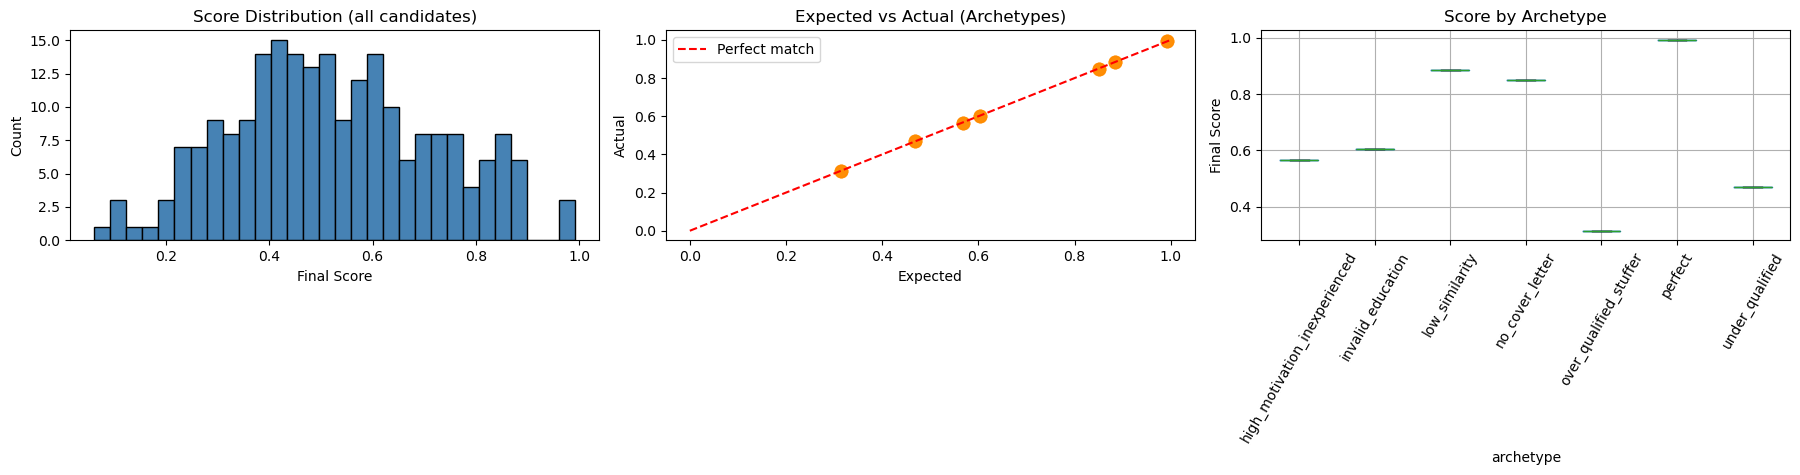

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Score distribution (all candidates)
axes[0].hist(res_df['actual'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Score Distribution (all candidates)")
axes[0].set_xlabel("Final Score")
axes[0].set_ylabel("Count")

# Panel 2: Expected vs Actual (archetypes)
ax = axes[1]
ax.scatter(arch_res['expected'], arch_res['actual'], s=80, alpha=0.7, color='darkorange')
ax.plot([0,1], [0,1], 'r--', label='Perfect match')
ax.set_xlabel("Expected")
ax.set_ylabel("Actual")
ax.set_title("Expected vs Actual (Archetypes)")
ax.legend()

# Panel 3: Boxplot of actual score by archetype
arch_res.boxplot(column='actual', by='archetype', ax=axes[2], rot=60)
axes[2].set_title("Score by Archetype")
axes[2].set_ylabel("Final Score")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [32]:
df.to_csv('synthetic_candidates_final.csv', index=False)
res_df.to_csv('synthetic_scores_final.csv', index=False)
summary.to_csv('archetype_test_report_final.csv', index=False)
print("Saved 3 CSVs:")
print("  - synthetic_candidates_final.csv")
print("  - synthetic_scores_final.csv")
print("  - archetype_test_report_final.csv")

Saved 3 CSVs:
  - synthetic_candidates_final.csv
  - synthetic_scores_final.csv
  - archetype_test_report_final.csv


In [1]:
import pandas as pd

# 1. Look at what YOUR generator produced
your_df = pd.read_csv('synthetic_candidates_final.csv')
print("=== YOUR DATA (synthetic_candidates_final.csv) ===")
print("Columns:", list(your_df.columns))
print("Shape:", your_df.shape)
print()
print(your_df.head(3).to_string())

=== YOUR DATA (synthetic_candidates_final.csv) ===
Columns: ['experience_years', 'education_level', 'skills', 'has_cover_letter', 'cover_letter_similarity', 'expected_score', 'name', 'archetype']
Shape: (221, 8)

   experience_years education_level                       skills  has_cover_letter  cover_letter_similarity  expected_score          name archetype
0                 5          Master  ['Python', 'SQL', 'Docker']              True                     0.95          0.9925  perfect_1803   perfect
1                 5          Master  ['Python', 'SQL', 'Docker']              True                     0.95          0.9925  perfect_7964   perfect
2                 5          Master  ['Python', 'SQL', 'Docker']              True                     0.95          0.9925  perfect_6890   perfect


In [2]:
import numpy as np

# ---- Besu's ideal_profile.py logic (inlined) ----
EDU_LEVELS = {'Bachelor': 1, 'Master': 2, 'PhD': 3}
TARGET_EDU_LEVEL = 'Master'
TARGET_EXPERIENCE_YEARS = 1.5

WEIGHTS = {
    'experience': 0.35,
    'education': 0.15,
    'skills': 0.35,
    'motivation': 0.15,
}

def score_experience(exp_years, target=TARGET_EXPERIENCE_YEARS, tolerance=1.3):
    return float(np.exp(-0.5 * ((exp_years - target) / tolerance) ** 2))

def score_education(edu_level, target=TARGET_EDU_LEVEL):
    cand_val = EDU_LEVELS.get(edu_level, None)
    target_val = EDU_LEVELS.get(target, 2)
    if cand_val is None:
        return 0.0
    return max(0.0, 1.0 - 0.3 * abs(cand_val - target_val))

def score_skills(matched, num_requested, num_listed):
    if num_requested <= 0:
        return 0.0
    match_ratio = matched / num_requested
    extra = max(0, num_listed - matched)
    focus_bonus = 1.0 / (1.0 + 0.15 * extra)
    return float(match_ratio * focus_bonus)

def score_motivation(sim, threshold=0.75):
    sim = max(0.0, min(1.0, sim))
    return sim if sim >= threshold else sim * 0.85

def ideal_profile_score(exp_years, edu_level, matched, num_requested,
                         num_listed, cover_letter_similarity, weights=None):
    w = weights or WEIGHTS
    sub = {
        'experience': score_experience(exp_years),
        'education':  score_education(edu_level),
        'skills':     score_skills(matched, num_requested, num_listed),
        'motivation': score_motivation(cover_letter_similarity),
    }
    final = sum(sub[k] * w[k] for k in w)
    return {'fit_label': round(final, 4), 'sub_scores': sub}

print("Besu's scoring logic loaded.")

Besu's scoring logic loaded.


In [4]:
import pandas as pd
import ast

your_df = pd.read_csv('synthetic_candidates_final.csv')

# Diagnose: find rows that are NOT strings, or fail to parse
def safe_parse(x):
    if not isinstance(x, str):
        return None
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

parsed = your_df['skills'].apply(safe_parse)

# Report bad rows
bad_mask = parsed.isna()
print(f"Total rows: {len(your_df)}")
print(f"Bad/unparseable rows: {bad_mask.sum()}")

if bad_mask.sum() > 0:
    print("\nSample bad values:")
    print(your_df.loc[bad_mask, 'skills'].head(10).tolist())

# Assign only the good ones
your_df['skills'] = parsed

print("\nAfter conversion:")
print("  skills[0] type:", type(your_df['skills'].iloc[0]))
print("  skills[0] value:", your_df['skills'].iloc[0])

Total rows: 221
Bad/unparseable rows: 198

Sample bad values:
["[np.str_('AWS'), np.str_('SQL'), np.str_('JavaScript'), np.str_('Go')]", "[np.str_('Docker'), np.str_('AWS'), np.str_('SQL'), np.str_('Git'), np.str_('Linux'), np.str_('Kubernetes')]", "[np.str_('AWS'), np.str_('C#')]", "[np.str_('Python'), np.str_('Docker'), np.str_('SQL'), np.str_('Scala'), np.str_('R'), np.str_('Ansible')]", "[np.str_('SQL'), np.str_('Docker'), np.str_('Git'), np.str_('Python'), np.str_('Kubernetes'), np.str_('React')]", "[np.str_('Docker'), np.str_('AWS'), np.str_('Python'), np.str_('SQL'), np.str_('Git'), np.str_('Ansible'), np.str_('Node.js'), np.str_('Go')]", "[np.str_('SQL'), np.str_('Git')]", "[np.str_('SQL'), np.str_('Git'), np.str_('Kubernetes'), np.str_('JavaScript'), np.str_('Terraform')]", "[np.str_('Git')]", "[np.str_('Git'), np.str_('Python'), np.str_('AWS'), np.str_('Docker')]"]

After conversion:
  skills[0] type: <class 'list'>
  skills[0] value: ['Python', 'SQL', 'Docker']


In [5]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)

# --- 1. Job spec (defines what candidates are evaluated against) ---
JOB_SPEC = {
    'target_experience_years': 1.5,
    'target_education_level': 'Master',
    'requested_skills': ['Python', 'SQL', 'Docker'],   # 3 skills requested
}

REQUIRED_SET = set(JOB_SPEC['requested_skills'])

# --- 2. All skills that could appear on a candidate's profile ---
ALL_SKILLS = ['Python','SQL','Docker','AWS','Git','Java','C++','Linux',
              'JavaScript','React','Node.js','Go','Ruby','C#','R',
              'Scala','Kubernetes','Terraform','Ansible','Spark']

# --- 3. Your archetypes (kept from before), expressed in HIS schema terms ---
ARCHETYPES = {
    'perfect': {
        'experience_years': 1.5,
        'education_level': 'Master',
        'matched_skills': ['Python', 'SQL', 'Docker'],   # all 3 matched
        'extra_skills': [],
        'cover_letter_similarity': 0.95,
    },
    'under_qualified': {
        'experience_years': 0.4,
        'education_level': 'Bachelor',
        'matched_skills': ['Python', 'SQL'],
        'extra_skills': [],
        'cover_letter_similarity': 0.85,
    },
    'over_qualified_stuffer': {
        'experience_years': 8.0,
        'education_level': 'PhD',
        'matched_skills': ['Python', 'SQL', 'Docker'],
        'extra_skills': ['AWS', 'Git', 'Java', 'C++', 'Linux'],  # 5 extra
        'cover_letter_similarity': 0.25,
    },
    'no_cover_letter': {
        'experience_years': 1.5,
        'education_level': 'Master',
        'matched_skills': ['Python', 'SQL', 'Docker'],
        'extra_skills': [],
        'cover_letter_similarity': 0.0,   # similarity = 0 means no letter
    },
    'invalid_education': {
        'experience_years': 1.2,
        'education_level': 'High School',   # not in EDU_LEVELS → invalid
        'matched_skills': ['Python', 'SQL'],
        'extra_skills': [],
        'cover_letter_similarity': 0.60,
    },
    'low_similarity': {
        'experience_years': 1.5,
        'education_level': 'Master',
        'matched_skills': ['Python', 'SQL', 'Docker'],
        'extra_skills': [],
        'cover_letter_similarity': 0.05,
    },
    'high_motivation_inexperienced': {
        'experience_years': 0.5,
        'education_level': 'Bachelor',
        'matched_skills': ['Python', 'SQL', 'Docker'],
        'extra_skills': [],
        'cover_letter_similarity': 0.98,
    },
}

# --- 4. Build one row in HIS schema ---
def make_row_from_archetype(name, arche):
    matched = len(set(arche['matched_skills']) & REQUIRED_SET)
    listed_skills = arche['matched_skills'] + arche['extra_skills']
    num_listed = len(listed_skills)
    num_requested = len(REQUIRED_SET)

    row = {
        'name': name,
        'archetype': name.split('_')[0],   # rough tag; fine for grouping
        'experience_years': arche['experience_years'],
        'education_level': arche['education_level'],
        'num_matched': matched,
        'num_requested': num_requested,
        'num_listed': num_listed,
        'cover_letter_similarity': arche['cover_letter_similarity'],
    }
    return row


# --- 5. Random candidate generator (realistic distribution) ---
def make_random_row(i):
    exp = max(0.0, float(rng.normal(2.0, 2.0)))
    edu = rng.choice(['Bachelor', 'Master', 'PhD'],
                     p=[0.45, 0.40, 0.15])
    n_matched = int(rng.integers(0, len(REQUIRED_SET) + 1))
    matched = list(rng.choice(list(REQUIRED_SET),
                              size=n_matched, replace=False))
    non_req = [s for s in ALL_SKILLS if s not in REQUIRED_SET]
    n_extra = int(rng.integers(0, 5))
    extra = list(rng.choice(non_req, size=n_extra, replace=False))
    sim = float(np.clip(rng.beta(2, 2), 0, 1))

    return {
        'name': f'random_{i:04d}',
        'archetype': 'random',
        'experience_years': round(exp, 2),
        'education_level': edu,
        'num_matched': n_matched,
        'num_requested': len(REQUIRED_SET),
        'num_listed': n_matched + n_extra,
        'cover_letter_similarity': round(sim, 3),
    }


# --- 6. Generate full dataset ---
rows = []
for arche_name, arche in ARCHETYPES.items():
    for k in range(3):    # 3 copies per archetype
        rows.append(make_row_from_archetype(f"{arche_name}_{k+1}", arche))

for i in range(200):     # 200 random candidates
    rows.append(make_random_row(i))

df = pd.DataFrame(rows)
print(f"Generated {len(df)} candidates")
print("Columns:", list(df.columns))
print()
print(df.head(10).to_string(index=False))

Generated 221 candidates
Columns: ['name', 'archetype', 'experience_years', 'education_level', 'num_matched', 'num_requested', 'num_listed', 'cover_letter_similarity']

                    name archetype  experience_years education_level  num_matched  num_requested  num_listed  cover_letter_similarity
               perfect_1   perfect               1.5          Master            3              3           3                     0.95
               perfect_2   perfect               1.5          Master            3              3           3                     0.95
               perfect_3   perfect               1.5          Master            3              3           3                     0.95
       under_qualified_1     under               0.4        Bachelor            2              3           2                     0.85
       under_qualified_2     under               0.4        Bachelor            2              3           2                     0.85
       under_qualified_3   

In [6]:
# Apply Besu's scoring function to every row
labels = []
sub_scores_list = []

for _, row in df.iterrows():
    result = ideal_profile_score(
        exp_years=row['experience_years'],
        edu_level=row['education_level'],
        matched=row['num_matched'],
        num_requested=row['num_requested'],
        num_listed=row['num_listed'],
        cover_letter_similarity=row['cover_letter_similarity'],
    )
    labels.append(result['fit_label'])
    sub_scores_list.append(result['sub_scores'])

df['fit_label'] = labels

# Show archetype rows (the first 21) to verify
print("=== Archetype rows (expected score) ===")
print(df.iloc[:21][['name', 'archetype', 'experience_years', 'education_level',
                     'num_matched', 'num_listed', 'cover_letter_similarity',
                     'fit_label']].to_string(index=False))

print(f"\nLabel range: {df['fit_label'].min():.4f} to {df['fit_label'].max():.4f}")
print(f"Label mean:  {df['fit_label'].mean():.4f}")

=== Archetype rows (expected score) ===
                           name archetype  experience_years education_level  num_matched  num_listed  cover_letter_similarity  fit_label
                      perfect_1   perfect               1.5          Master            3           3                     0.95     0.9925
                      perfect_2   perfect               1.5          Master            3           3                     0.95     0.9925
                      perfect_3   perfect               1.5          Master            3           3                     0.95     0.9925
              under_qualified_1     under               0.4        Bachelor            2           2                     0.85     0.7105
              under_qualified_2     under               0.4        Bachelor            2           2                     0.85     0.7105
              under_qualified_3     under               0.4        Bachelor            2           2                     0.85     0.7105
 

In [7]:
import os

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

df.to_csv('data/synthetic_candidates.csv', index=False)

print(f"Saved -> data/synthetic_candidates.csv")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Saved -> data/synthetic_candidates.csv
Rows: 221
Columns: ['name', 'archetype', 'experience_years', 'education_level', 'num_matched', 'num_requested', 'num_listed', 'cover_letter_similarity', 'fit_label']


In [8]:
import pandas as pd
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ---- Besu's features.py logic (inlined) ----
EDU_LEVELS = {'Bachelor': 1, 'Master': 2, 'PhD': 3}
TARGET_EXPERIENCE = 1.5
TARGET_EDU_VAL = EDU_LEVELS['Master']

FEATURE_COLUMNS = [
    'experience_distance',
    'education_distance',
    'skill_match_ratio',
    'skill_num_listed',
    'skill_focus_ratio',
    'cover_letter_similarity',
]

def build_features(df):
    feats = pd.DataFrame(index=df.index)
    feats['experience_distance'] = (df['experience_years'] - TARGET_EXPERIENCE).abs()
    edu_val = df['education_level'].map(EDU_LEVELS).fillna(0)
    feats['education_distance'] = (edu_val - TARGET_EDU_VAL).abs()
    feats['skill_match_ratio'] = df['num_matched'] / df['num_requested'].clip(lower=1)
    feats['skill_num_listed'] = df['num_listed']
    feats['skill_focus_ratio'] = df['num_matched'] / df['num_listed'].clip(lower=1)
    feats['cover_letter_similarity'] = df['cover_letter_similarity']
    return feats[FEATURE_COLUMNS]

# ---- Besu's train.py logic (inlined) ----
def train_and_evaluate(df, model_out_path):
    X = build_features(df)
    y = df['fit_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    importances = pd.Series(model.feature_importances_,
                             index=FEATURE_COLUMNS).sort_values(ascending=False)

    joblib.dump(model, model_out_path)

    return {
        'mae': mae, 'r2': r2,
        'n_train': len(X_train), 'n_test': len(X_test),
        'feature_importances': importances,
        'model': model,
    }

print("Besu's features + training logic loaded.")

Besu's features + training logic loaded.


In [9]:
# Load your saved dataset
df_train = pd.read_csv('data/synthetic_candidates.csv')
print(f"Training on {len(df_train)} rows...")

results = train_and_evaluate(df_train, 'models/fit_model.joblib')

print(f"\nTrain size: {results['n_train']}")
print(f"Test size:  {results['n_test']}")
print(f"\nTest MAE: {results['mae']:.4f}   (lower is better; ~0 = perfect)")
print(f"Test R²:  {results['r2']:.4f}   (closer to 1 = better)")
print(f"\nFeature importances (what the model learned to weigh):")
print(results['feature_importances'].to_string())

Training on 221 rows...

Train size: 176
Test size:  45

Test MAE: 0.0149   (lower is better; ~0 = perfect)
Test R²:  0.9823   (closer to 1 = better)

Feature importances (what the model learned to weigh):
experience_distance        0.483076
skill_match_ratio          0.290445
skill_focus_ratio          0.129608
cover_letter_similarity    0.071144
education_distance         0.021732
skill_num_listed           0.003995


In [10]:
# Build a set of "new" candidates the model has never seen
new_candidates = pd.DataFrame([
    # Should score very high (near perfect)
    {'name': 'Near-ideal', 'archetype': 'test',
     'experience_years': 1.6, 'education_level': 'Master',
     'num_matched': 3, 'num_requested': 3, 'num_listed': 3,
     'cover_letter_similarity': 0.88},

    # Should score low (over-qualified + stuffer + weak letter)
    {'name': 'Senior stuffer', 'archetype': 'test',
     'experience_years': 8.0, 'education_level': 'PhD',
     'num_matched': 3, 'num_requested': 3, 'num_listed': 9,
     'cover_letter_similarity': 0.35},

    # Should score mid (under-skilled but motivated)
    {'name': 'Junior motivated', 'archetype': 'test',
     'experience_years': 0.4, 'education_level': 'Bachelor',
     'num_matched': 1, 'num_requested': 3, 'num_listed': 1,
     'cover_letter_similarity': 0.91},

    # Should score mid-high (right exp, slightly wrong edu)
    {'name': 'Right exp, wrong edu', 'archetype': 'test',
     'experience_years': 1.4, 'education_level': 'Bachelor',
     'num_matched': 3, 'num_requested': 3, 'num_listed': 4,
     'cover_letter_similarity': 0.79},
])

# Score them with the trained model
X_new = build_features(new_candidates)
new_candidates['predicted_fit'] = results['model'].predict(X_new).round(4)

# Also compute the "ground truth" using Besu's rule-based formula
new_candidates['rule_score'] = [
    ideal_profile_score(
        row['experience_years'], row['education_level'],
        row['num_matched'], row['num_requested'], row['num_listed'],
        row['cover_letter_similarity']
    )['fit_label']
    for _, row in new_candidates.iterrows()
]

new_candidates['diff'] = (new_candidates['predicted_fit']
                          - new_candidates['rule_score']).round(4)

print(new_candidates[['name', 'rule_score', 'predicted_fit', 'diff']].to_string(index=False))

                name  rule_score  predicted_fit    diff
          Near-ideal      0.9810         0.9422 -0.0388
      Senior stuffer      0.3338         0.3386  0.0048
    Junior motivated      0.6028         0.6063  0.0035
Right exp, wrong edu      0.8768         0.8623 -0.0145


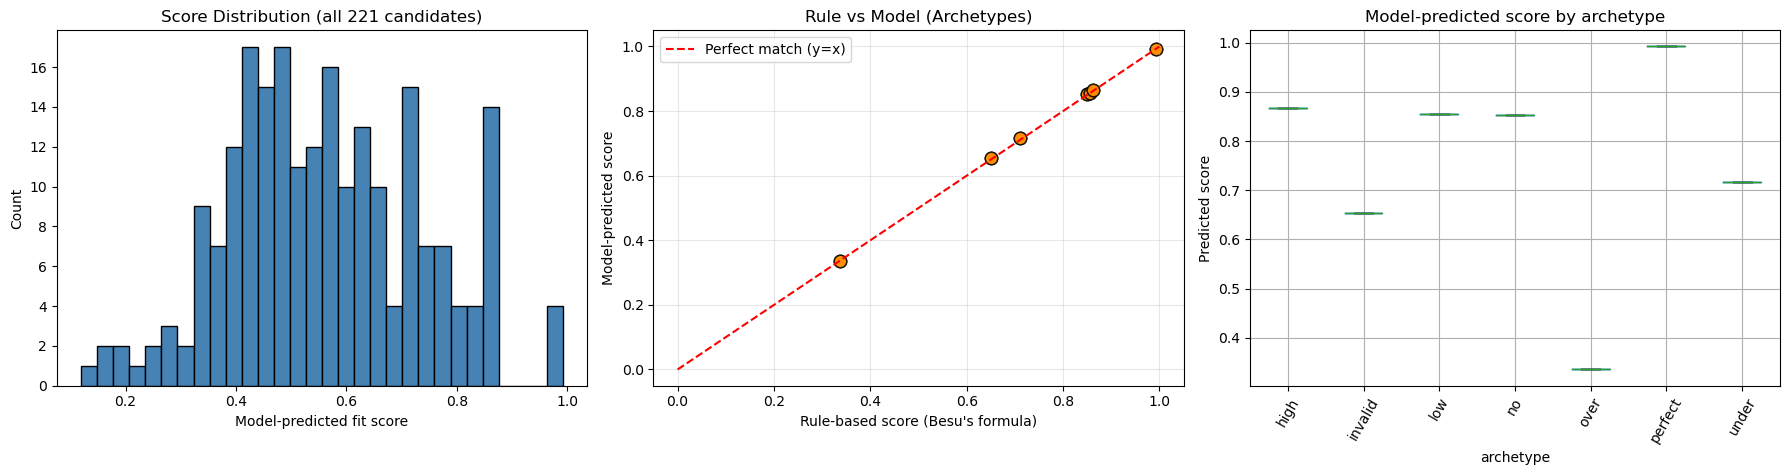

In [11]:
import matplotlib.pyplot as plt

# Score every candidate in the training set through the trained model
all_X = build_features(df_train)
df_scored = df_train.copy()
df_scored['actual'] = results['model'].predict(all_X).round(4)
df_scored['expected'] = df_scored['fit_label']

# Split archetypes from random
arch_scored = df_scored[df_scored['archetype'] != 'random'].copy()
rand_scored = df_scored[df_scored['archetype'] == 'random'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Score distribution
axes[0].hist(df_scored['actual'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Score Distribution (all 221 candidates)")
axes[0].set_xlabel("Model-predicted fit score")
axes[0].set_ylabel("Count")

# Panel 2: Expected (rule) vs Predicted (model) for archetypes
ax = axes[1]
ax.scatter(arch_scored['expected'], arch_scored['actual'],
           s=80, alpha=0.7, color='darkorange', edgecolor='black')
ax.plot([0, 1], [0, 1], 'r--', label='Perfect match (y=x)')
ax.set_xlabel("Rule-based score (Besu's formula)")
ax.set_ylabel("Model-predicted score")
ax.set_title("Rule vs Model (Archetypes)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Score by archetype
arch_scored.boxplot(column='actual', by='archetype', ax=axes[2], rot=60)
axes[2].set_title("Model-predicted score by archetype")
axes[2].set_ylabel("Predicted score")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [12]:
import os

os.makedirs('outputs', exist_ok=True)

# 1. Save the scored dataset (with model predictions)
df_scored.to_csv('outputs/scored_candidates.csv', index=False)

# 2. Save the test candidates with rule vs model comparison
new_candidates.to_csv('outputs/new_candidate_predictions.csv', index=False)

# 3. Save the training results summary
summary_df = pd.DataFrame([
    {'metric': 'train_size',  'value': results['n_train']},
    {'metric': 'test_size',   'value': results['n_test']},
    {'metric': 'test_MAE',    'value': round(results['mae'], 4)},
    {'metric': 'test_R2',     'value': round(results['r2'], 4)},
])
for feat, imp in results['feature_importances'].items():
    summary_df.loc[len(summary_df)] = [f'importance_{feat}', round(imp, 4)]

summary_df.to_csv('outputs/training_summary.csv', index=False)

print("Saved 3 files:")
print("  - outputs/scored_candidates.csv       (all 221 with model predictions)")
print("  - outputs/new_candidate_predictions.csv (4 new candidates, rule vs model)")
print("  - outputs/training_summary.csv         (metrics + feature importances)")
print()
print("Model file:")
print("  - models/fit_model.joblib")

Saved 3 files:
  - outputs/scored_candidates.csv       (all 221 with model predictions)
  - outputs/new_candidate_predictions.csv (4 new candidates, rule vs model)
  - outputs/training_summary.csv         (metrics + feature importances)

Model file:
  - models/fit_model.joblib


In [13]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/synthetic_candidates.csv', index=False)
print("Saved YOUR 221 rows -> data/synthetic_candidates.csv")
print("Rows:", len(df))
print("Columns:", list(df.columns))

Saved YOUR 221 rows -> data/synthetic_candidates.csv
Rows: 221
Columns: ['name', 'archetype', 'experience_years', 'education_level', 'num_matched', 'num_requested', 'num_listed', 'cover_letter_similarity', 'fit_label']


In [14]:
import os
print("Notebook cwd:", os.getcwd())
print()
print("Path of saved file:", os.path.abspath('data/synthetic_candidates.csv'))
print("File exists?", os.path.exists('data/synthetic_candidates.csv'))
print("Size (bytes):", os.path.getsize('data/synthetic_candidates.csv') if os.path.exists('data/synthetic_candidates.csv') else 'N/A')

Notebook cwd: /home/elias

Path of saved file: /home/elias/data/synthetic_candidates.csv
File exists? True
Size (bytes): 11276


In [15]:
# Save directly to Besu's project folder using ABSOLUTE path
target = '/home/elias/job-candidate-selection/data/synthetic_candidates.csv'
df.to_csv(target, index=False)
print(f"Saved -> {target}")
print(f"Rows: {len(df)}")

Saved -> /home/elias/job-candidate-selection/data/synthetic_candidates.csv
Rows: 221
